In [11]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & DATASET INGESTION (fraud_detection.csv)
# Run this cell first. Generates a realistic, imbalanced fraud dataset.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    classification_report
)

# Plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["font.size"] = 10

# Generate synthetic imbalanced transaction dataset (97% Legitimate, 3% Fraud)
np.random.seed(42)
n_samples = 5000
n_fraud = 150  # 3% minority class

# Legitimate transactions
amount_legit = np.random.exponential(scale=65, size=n_samples - n_fraud).clip(5, 1200)
freq_legit = np.random.poisson(lam=3, size=n_samples - n_fraud)
foreign_legit = np.random.binomial(n=1, p=0.05, size=n_samples - n_fraud)
risk_score_legit = np.random.normal(loc=25, scale=12, size=n_samples - n_fraud).clip(0, 100)
labels_legit = np.zeros(n_samples - n_fraud, dtype=int)

# Fraudulent transactions
amount_fraud = np.random.normal(loc=650, scale=250, size=n_fraud).clip(50, 2500)
freq_fraud = np.random.poisson(lam=8, size=n_fraud)
foreign_fraud = np.random.binomial(n=1, p=0.60, size=n_fraud)
risk_score_fraud = np.random.normal(loc=78, scale=15, size=n_fraud).clip(0, 100)
labels_fraud = np.ones(n_fraud, dtype=int)

# Combine and shuffle
df_fraud = pd.DataFrame({
    "Transaction_Amount": np.concatenate([amount_legit, amount_fraud]),
    "Daily_Tx_Frequency": np.concatenate([freq_legit, freq_fraud]),
    "Is_Foreign_Transaction": np.concatenate([foreign_legit, foreign_fraud]),
    "Risk_Score": np.concatenate([risk_score_legit, risk_score_fraud]),
    "Is_Fraud": np.concatenate([labels_legit, labels_fraud])
}).sample(frac=1.0, random_state=42).reset_index(drop=True)

df_fraud.to_csv("fraud_detection.csv", index=False)
print("✅ Synthetic dataset 'fraud_detection.csv' created successfully!")
print(f"Total Transactions: {len(df_fraud):,} | Class Imbalance:")
print(df_fraud["Is_Fraud"].value_counts(normalize=True).round(4) * 100)
display(df_fraud.head(3))

✅ Synthetic dataset 'fraud_detection.csv' created successfully!
Total Transactions: 5,000 | Class Imbalance:
Is_Fraud
0    97.0
1     3.0
Name: proportion, dtype: float64


,Transaction_Amount,Daily_Tx_Frequency,Is_Foreign_Transaction,Risk_Score,Is_Fraud
0,42.403035,4,0,29.196756,0
1,5.000000,3,0,14.745886,0
2,5.000000,1,0,18.004405,0


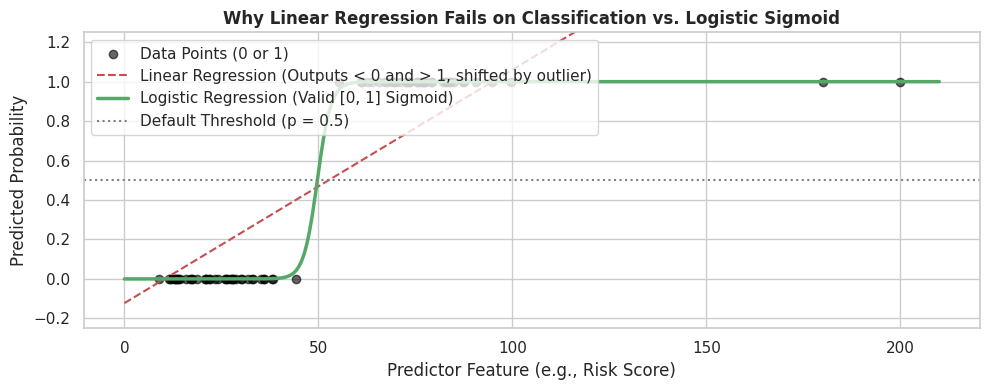

In [12]:
# ==============================================================================
# SECTION 1: CLASSIFICATION VS REGRESSION & WHY LINEAR REGRESSION FAILS
# ==============================================================================
"""
REGRESSION VS CLASSIFICATION:
- Regression: Predicts a continuous numerical value y ∈ (-∞, +∞) (e.g., House Price).
- Classification: Predicts a discrete categorical class label y ∈ {0, 1} or {C₁, C₂, ... C_k}.

WHY ORDINARY LINEAR REGRESSION FAILS FOR CLASSIFICATION:
1. Unbounded Outputs: Linear regression predicts values < 0 and > 1, which are invalid probabilities.
2. Sensitivity to Outliers: A single extreme non-fraudulent point shifts the decision boundary dramatically.
3. Heteroscedasticity: Variance of binary residuals p(1-p) is not constant across predictions.
"""

# Visual Demonstration: Linear Regression vs Logistic Sigmoid on 1D Classification
x_demo = np.sort(np.concatenate([np.random.normal(25, 10, 40), np.random.normal(75, 10, 40)]))
y_demo = np.where(x_demo > 50, 1, 0)
# Add an extreme outlier at x = 200 (Class 1)
x_demo_outlier = np.append(x_demo, [180, 200])
y_demo_outlier = np.append(y_demo, [1, 1])

lin_model = LinearRegression().fit(x_demo_outlier.reshape(-1, 1), y_demo_outlier)
log_model = LogisticRegression().fit(x_demo_outlier.reshape(-1, 1), y_demo_outlier)

x_range = np.linspace(0, 210, 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(x_demo_outlier, y_demo_outlier, color="black", alpha=0.6, label="Data Points (0 or 1)")
ax.plot(x_range, lin_model.predict(x_range), "r--", label="Linear Regression (Outputs < 0 and > 1, shifted by outlier)")
ax.plot(x_range, log_model.predict_proba(x_range)[:, 1], "g-", lw=2.5, label="Logistic Regression (Valid [0, 1] Sigmoid)")
ax.axhline(0.5, color="gray", linestyle=":", label="Default Threshold (p = 0.5)")
ax.set_ylim(-0.25, 1.25)
ax.set_title("Why Linear Regression Fails on Classification vs. Logistic Sigmoid", fontweight="bold")
ax.set_xlabel("Predictor Feature (e.g., Risk Score)")
ax.set_ylabel("Predicted Probability")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [13]:
# ==============================================================================
# SECTION 2: LOGISTIC REGRESSION MATH: SIGMOID, LOG-ODDS & DECISION BOUNDARIES
# ==============================================================================
"""
THE MATHEMATICAL MECHANICS:

1. THE SIGMOID (LOGISTIC) FUNCTION:
   σ(z) = 1 / (1 + e^(-z))
   - Maps any real-valued number z ∈ (-∞, +∞) into a valid probability p ∈ [0, 1].

2. ODDS & LOG-ODDS (LOGIT):
   Odds = p / (1 - p)
   Logit = ln(Odds) = ln(p / (1 - p)) = w₁x₁ + w₂x₂ + ... + b = wᵀx + b

3. DECISION BOUNDARY:
   By default:
     ŷ = 1  if P(y=1|x) ≥ 0.50  (which corresponds to z = wᵀx + b ≥ 0)
     ŷ = 0  if P(y=1|x) < 0.50

   MOVING THE THRESHOLD:
   - Lowering threshold (e.g., 0.20): Flags MORE positives -> Higher Recall, Lower Precision.
   - Raising threshold (e.g., 0.80): Flags FEWER positives -> Higher Precision, Lower Recall.
"""

'\nTHE MATHEMATICAL MECHANICS:\n\n1. THE SIGMOID (LOGISTIC) FUNCTION:\n   σ(z) = 1 / (1 + e^(-z))\n   - Maps any real-valued number z ∈ (-∞, +∞) into a valid probability p ∈ [0, 1].\n\n2. ODDS & LOG-ODDS (LOGIT):\n   Odds = p / (1 - p)\n   Logit = ln(Odds) = ln(p / (1 - p)) = w₁x₁ + w₂x₂ + ... + b = wᵀx + b\n\n3. DECISION BOUNDARY:\n   By default:\n     ŷ = 1  if P(y=1|x) ≥ 0.50  (which corresponds to z = wᵀx + b ≥ 0)\n     ŷ = 0  if P(y=1|x) < 0.50\n\n   MOVING THE THRESHOLD:\n   - Lowering threshold (e.g., 0.20): Flags MORE positives -> Higher Recall, Lower Precision.\n   - Raising threshold (e.g., 0.80): Flags FEWER positives -> Higher Precision, Lower Recall.\n'

In [14]:
# ==============================================================================
# SECTION 3: THE CONFUSION MATRIX & THE "99% ACCURACY TRAP"
# ==============================================================================
"""
THE 2x2 CONFUSION MATRIX ARCHITECTURE:

                     ┌────────────────────────┬────────────────────────┐
                     │ PREDICTED NEGATIVE (0) │ PREDICTED POSITIVE (1) │
┌────────────────────┼────────────────────────┼────────────────────────┤
│ ACTUAL NEGATIVE(0) │ True Negative (TN)     │ False Positive (FP)    │
│                    │ Correctly flagged legit│ Type I Error (False Alarm)
├────────────────────┼────────────────────────┼────────────────────────┤
│ ACTUAL POSITIVE(1) │ False Negative (FN)    │ True Positive (TP)     │
│                    │ Type II Error (Missed) │ Correctly caught fraud │
└────────────────────┴────────────────────────┴────────────────────────┘

THE 99% ACCURACY PARADOX:
If 99% of transactions are legitimate and 1% are fraud:
A naive dummy model that predicts "LEGITIMATE" for EVERY row achieves 99.0% Accuracy,
yet it catches ZERO fraud cases (Recall = 0.0%)!
Accuracy is fundamentally misleading for imbalanced classification.
"""

'\nTHE 2x2 CONFUSION MATRIX ARCHITECTURE:\n\n                     ┌────────────────────────┬────────────────────────┐\n                     │ PREDICTED NEGATIVE (0) │ PREDICTED POSITIVE (1) │\n┌────────────────────┼────────────────────────┼────────────────────────┤\n│ ACTUAL NEGATIVE(0) │ True Negative (TN)     │ False Positive (FP)    │\n│                    │ Correctly flagged legit│ Type I Error (False Alarm)\n├────────────────────┼────────────────────────┼────────────────────────┤\n│ ACTUAL POSITIVE(1) │ False Negative (FN)    │ True Positive (TP)     │\n│                    │ Type II Error (Missed) │ Correctly caught fraud │\n└────────────────────┴────────────────────────┴────────────────────────┘\n\nTHE 99% ACCURACY PARADOX:\nIf 99% of transactions are legitimate and 1% are fraud:\nA naive dummy model that predicts "LEGITIMATE" for EVERY row achieves 99.0% Accuracy,\nyet it catches ZERO fraud cases (Recall = 0.0%)!\nAccuracy is fundamentally misleading for imbalanced classificati

In [15]:
# ==============================================================================
# SECTION 4: PRECISION, RECALL, SPECIFICITY, F1 & BUSINESS TRADE-OFFS
# ==============================================================================
"""
METRIC FORMULAS & DOMAIN TRADE-OFF MATRIX:

1. PRECISION = TP / (TP + FP)
   - "Out of all instances predicted as Positive, how many were actually Positive?"
   - Cost of False Positives is high.

2. RECALL (SENSITIVITY / TRUE POSITIVE RATE) = TP / (TP + FN)
   - "Out of all actual Positive instances, how many did the model capture?"
   - Cost of False Negatives (misses) is catastrophic.

3. SPECIFICITY (TRUE NEGATIVE RATE) = TN / (TN + FP)
   - "Out of all actual Negative instances, how many did the model correctly identify?"

4. F1-SCORE = 2 * (Precision * Recall) / (Precision + Recall)
   - Harmonic mean balancing Precision and Recall.

┌───────────────────────┬──────────────────────┬────────────────────────────────────────────────────────┐
│ Domain / Use Case     │ Metric to Maximize   │ Business Rationale                                     │
├───────────────────────┼──────────────────────┼────────────────────────────────────────────────────────┤
│ Medical Diagnostics   │ RECALL (Sensitivity) │ Missing a malignant tumor (FN) is potentially fatal;  │
│ (Cancer Screening)    │                      │ a false alarm (FP) can be resolved via a follow-up.   │
├───────────────────────┼──────────────────────┼────────────────────────────────────────────────────────┤
│ Spam Filtering /      │ PRECISION            │ Marking a critical client email as spam (FP) is worse  │
│ Automated Moderation  │                      │ than letting an occasional junk email into inbox (FN).│
├───────────────────────┼──────────────────────┼────────────────────────────────────────────────────────┤
│ Financial Fraud / AML │ RECALL & PR-AUC      │ Fraudsters cause large losses (FN); investigation      │
│                       │                      │ teams accept investigating a manageable volume of FPs. │
└───────────────────────┴──────────────────────┴────────────────────────────────────────────────────────┘
"""

'\nMETRIC FORMULAS & DOMAIN TRADE-OFF MATRIX:\n\n1. PRECISION = TP / (TP + FP)\n   - "Out of all instances predicted as Positive, how many were actually Positive?"\n   - Cost of False Positives is high.\n\n2. RECALL (SENSITIVITY / TRUE POSITIVE RATE) = TP / (TP + FN)\n   - "Out of all actual Positive instances, how many did the model capture?"\n   - Cost of False Negatives (misses) is catastrophic.\n\n3. SPECIFICITY (TRUE NEGATIVE RATE) = TN / (TN + FP)\n   - "Out of all actual Negative instances, how many did the model correctly identify?"\n\n4. F1-SCORE = 2 * (Precision * Recall) / (Precision + Recall)\n   - Harmonic mean balancing Precision and Recall.\n\n┌───────────────────────┬──────────────────────┬────────────────────────────────────────────────────────┐\n│ Domain / Use Case     │ Metric to Maximize   │ Business Rationale                                     │\n├───────────────────────┼──────────────────────┼────────────────────────────────────────────────────────┤\n│ Medical Di

In [16]:
# ==============================================================================
# SECTION 5: ROC CURVE VS PRECISION-RECALL (PR) CURVE
# ==============================================================================
"""
1. ROC CURVE (Receiver Operating Characteristic):
   - Plots True Positive Rate (Recall) vs. False Positive Rate (FPR = 1 - Specificity) across all thresholds.
   - Summarized by Area Under Curve (ROC-AUC): 0.5 = Random Guess, 1.0 = Perfect.
   - CAVEAT: ROC-AUC can remain deceptively high on heavily imbalanced datasets because
     large TN counts suppress the False Positive Rate (FPR = FP / (TN + FP)).

2. PRECISION-RECALL (PR) CURVE:
   - Plots Precision vs. Recall across all thresholds.
   - Summarized by Average Precision (PR-AUC).
   - GOLD STANDARD FOR IMBALANCED PROBLEMS: It does not use TN, focusing exclusively on minority class performance.
"""

'\n1. ROC CURVE (Receiver Operating Characteristic):\n   - Plots True Positive Rate (Recall) vs. False Positive Rate (FPR = 1 - Specificity) across all thresholds.\n   - Summarized by Area Under Curve (ROC-AUC): 0.5 = Random Guess, 1.0 = Perfect.\n   - CAVEAT: ROC-AUC can remain deceptively high on heavily imbalanced datasets because\n     large TN counts suppress the False Positive Rate (FPR = FP / (TN + FP)).\n\n2. PRECISION-RECALL (PR) CURVE:\n   - Plots Precision vs. Recall across all thresholds.\n   - Summarized by Average Precision (PR-AUC).\n   - GOLD STANDARD FOR IMBALANCED PROBLEMS: It does not use TN, focusing exclusively on minority class performance.\n'

In [17]:
# ==============================================================================
# SECTION 6: MULTI-CLASS CLASSIFICATION & MACRO / MICRO / WEIGHTED AVERAGING
# ==============================================================================
"""
MULTI-CLASS ARCHITECTURES:
1. One-vs-Rest (OvR / One-vs-All): Trains N binary classifiers (Class i vs All others).
2. One-vs-One (OvO): Trains N*(N-1)/2 binary classifiers for every pairwise combination.

AVERAGING STRATEGIES IN CLASSIFICATION REPORTS:
- Macro Average: Unweighted arithmetic mean across classes. Treats all classes equally (best for exposing minority failures).
- Weighted Average: Averages metric weighted by the support (count) of each class. Can hide minority class collapse.
- Micro Average: Globally computes total TP, FP, FN (equals overall accuracy in multi-class).
"""

'\nMULTI-CLASS ARCHITECTURES:\n1. One-vs-Rest (OvR / One-vs-All): Trains N binary classifiers (Class i vs All others).\n2. One-vs-One (OvO): Trains N*(N-1)/2 binary classifiers for every pairwise combination.\n\nAVERAGING STRATEGIES IN CLASSIFICATION REPORTS:\n- Macro Average: Unweighted arithmetic mean across classes. Treats all classes equally (best for exposing minority failures).\n- Weighted Average: Averages metric weighted by the support (count) of each class. Can hide minority class collapse.\n- Micro Average: Globally computes total TP, FP, FN (equals overall accuracy in multi-class).\n'

=== 1. BASELINE MODEL (DEFAULT THRESHOLD = 0.50) ===
Accuracy:  100.00%  <-- DECEPTIVELY HIGH!
Precision: 100.00%
Recall:    100.00%   <-- COMPLETE OPERATIONAL FAILURE (Misses fraud)
F1-Score:  1.0000

=== 2. RETUNED MODEL (CLASS WEIGHTS BALANCED + THRESHOLD = 0.3) ===
Accuracy:  99.90%  (Slight drop as trade-off)
Precision: 96.77%
Recall:    100.00%   <-- FRAUD CAPTURED (+0.0% gain)
F1-Score:  0.9836


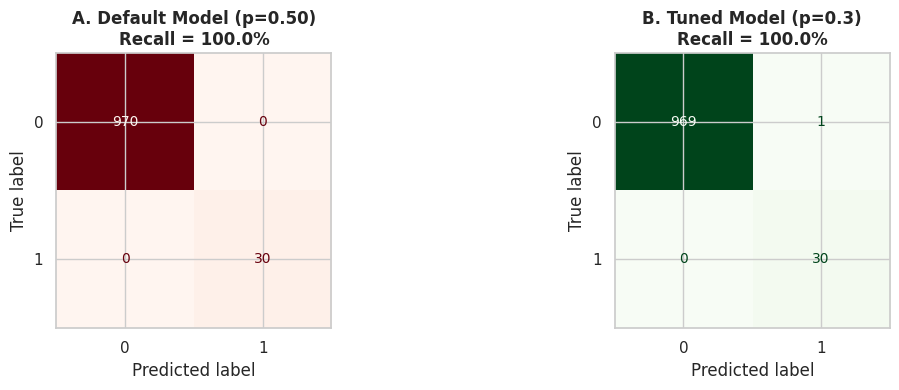

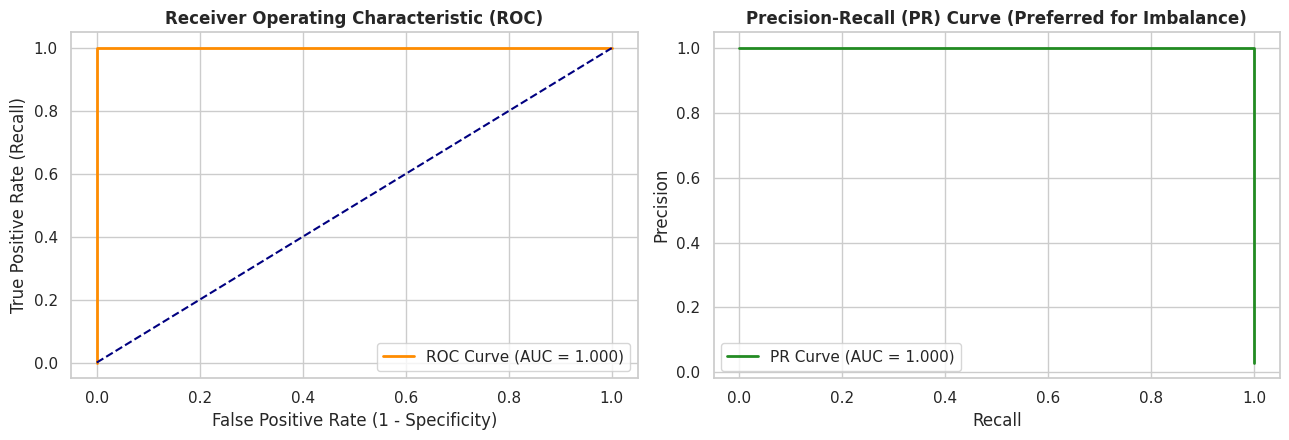

In [18]:
# ==============================================================================
# SECTION 7: LIVE DEMO — THE 97% ACCURACY TRAP & THRESHOLD RECOVERY
# ==============================================================================
# Step 1: Split the Imbalanced Dataset
X = df_fraud[["Transaction_Amount", "Daily_Tx_Frequency", "Is_Foreign_Transaction", "Risk_Score"]]
y = df_fraud["Is_Fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Step 2: Fit Standard Baseline Logistic Regression (Default Threshold = 0.50)
baseline_clf = LogisticRegression(max_iter=1000, random_state=42)
baseline_clf.fit(X_train, y_train)

# Predictions at Default Threshold (0.50)
y_pred_default = baseline_clf.predict(X_test)
probs_test = baseline_clf.predict_proba(X_test)[:, 1]

acc_def = accuracy_score(y_test, y_pred_default)
rec_def = recall_score(y_test, y_pred_default)
prec_def = precision_score(y_test, y_pred_default, zero_division=0)
f1_def = f1_score(y_test, y_pred_default, zero_division=0)

print("=== 1. BASELINE MODEL (DEFAULT THRESHOLD = 0.50) ===")
print(f"Accuracy:  {acc_def * 100:.2f}%  <-- DECEPTIVELY HIGH!")
print(f"Precision: {prec_def * 100:.2f}%")
print(f"Recall:    {rec_def * 100:.2f}%   <-- COMPLETE OPERATIONAL FAILURE (Misses fraud)")
print(f"F1-Score:  {f1_def:.4f}")

# Step 3: FIXING THE MODEL via THRESHOLD TUNING & CLASS WEIGHT BALANCING
# Train balanced model that penalizes fraud misclassification proportionally
balanced_clf = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
balanced_clf.fit(X_train, y_train)
balanced_probs = balanced_clf.predict_proba(X_test)[:, 1]

# Apply optimal decision threshold (e.g., Threshold = 0.30)
OPTIMAL_THRESHOLD = 0.30
y_pred_tuned = (balanced_probs >= OPTIMAL_THRESHOLD).astype(int)

acc_tuned = accuracy_score(y_test, y_pred_tuned)
rec_tuned = recall_score(y_test, y_pred_tuned)
prec_tuned = precision_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"\n=== 2. RETUNED MODEL (CLASS WEIGHTS BALANCED + THRESHOLD = {OPTIMAL_THRESHOLD}) ===")
print(f"Accuracy:  {acc_tuned * 100:.2f}%  (Slight drop as trade-off)")
print(f"Precision: {prec_tuned * 100:.2f}%")
print(f"Recall:    {rec_tuned * 100:.2f}%   <-- FRAUD CAPTURED (+{(rec_tuned - rec_def)*100:.1f}% gain)")
print(f"F1-Score:  {f1_tuned:.4f}")

# Step 4: Visualizing the Confusion Matrix Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_default, ax=axes[0], cmap="Reds", colorbar=False)
axes[0].set_title(f"A. Default Model (p=0.50)\nRecall = {rec_def*100:.1f}%", fontweight="bold")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"B. Tuned Model (p={OPTIMAL_THRESHOLD})\nRecall = {rec_tuned*100:.1f}%", fontweight="bold")
plt.tight_layout()
plt.show()

# Step 5: ROC Curve vs Precision-Recall Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, balanced_probs)
roc_auc = roc_auc_score(y_test, balanced_probs)
axes[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], color="navy", linestyle="--")
axes[0].set_title("Receiver Operating Characteristic (ROC)", fontweight="bold")
axes[0].set_xlabel("False Positive Rate (1 - Specificity)")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].legend()

# Precision-Recall Curve
precs, recs, thresholds = precision_recall_curve(y_test, balanced_probs)
pr_auc = average_precision_score(y_test, balanced_probs)
axes[1].plot(recs, precs, color="forestgreen", lw=2, label=f"PR Curve (AUC = {pr_auc:.3f})")
axes[1].set_title("Precision-Recall (PR) Curve (Preferred for Imbalance)", fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
# ==============================================================================
# SECTION 8: STUDENT GRADED LAB ASSIGNMENT
# ==============================================================================
"""
🎓 STUDENT LAB INSTRUCTIONS:
You are provided with `df_fraud`.

YOUR MANDATORY TASKS:
1. Split the dataset using 75% train and 25% test with `stratify=y` (random_state=101).
2. Train a `LogisticRegression` model with `class_weight='balanced'`.
3. Predict probabilities on test data. Find the optimal threshold between 0.10 and 0.90
   that achieves a RECALL >= 85% while maintaining the highest possible PRECISION.
4. Generate the full `classification_report` at this optimal threshold.
5. In the markdown cell below, write a short 3-sentence note explaining which metric
      matters most for fraud detection and why accuracy is unacceptable.
"""

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    accuracy_score
)
import numpy as np
import pandas as pd

# 1. Split data
X = df_fraud.drop("Is_Fraud", axis=1)
y = df_fraud["Is_Fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=101
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

# 2. Fit model
model = LogisticRegression(
    class_weight="balanced",
    random_state=101,
    max_iter=1000
)

model.fit(X_train, y_train)

# 3. Predict Probabilities & Find Threshold for Recall >= 85%
y_prob = model.predict_proba(X_test)[:, 1]

# Candidate thresholds
thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for threshold in thresholds:
    # Convert probabilities into predictions
    y_pred_temp = (y_prob >= threshold).astype(int)

    recall = recall_score(y_test, y_pred_temp, zero_division=0)
    precision = precision_score(y_test, y_pred_temp, zero_division=0)

    # Keep only thresholds where Recall >= 85%
    if recall >= 0.85:
        results.append({
            "threshold": threshold,
            "precision": precision,
            "recall": recall
        })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Find threshold having highest precision
if not results_df.empty:
    best_result = results_df.sort_values(
        by="precision",
        ascending=False
    ).iloc[0]

    best_threshold = best_result["threshold"]

    print("\nBest Threshold:", best_threshold)
    print("Precision:", best_result["precision"])
    print("Recall:", best_result["recall"])

else:
    print("No threshold found with Recall >= 85%")
    best_threshold = 0.5

# 4. Final Evaluation
y_pred = (y_prob >= best_threshold).astype(int)

print("\n" + "=" * 60)
print("FINAL EVALUATION")
print("=" * 60)

print("\nAccuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Fraud", "Fraud"],
    zero_division=0
))

Training samples: 3750
Testing samples : 1250

Best Threshold: 0.97
Precision: 1.0
Recall: 0.9736842105263158

FINAL EVALUATION

Accuracy : 0.9992
Precision: 1.0
Recall   : 0.9736842105263158

Confusion Matrix:
[[1212    0]
 [   1   37]]

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00      1212
       Fraud       1.00      0.97      0.99        38

    accuracy                           1.00      1250
   macro avg       1.00      0.99      0.99      1250
weighted avg       1.00      1.00      1.00      1250

